In [33]:
 # Library Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pandas_profiling as pp
warnings.filterwarnings("ignore")

In [2]:
 # Dataset Load
data  = pd.read_csv(r"C:\Users\visha\OneDrive\Documents\new projects\Ecommerce\Ecommerce_Delivery_Analytics_New.csv")
data.head(3)

,Order ID,Customer ID,Platform,Order Date & Time,Delivery Time (Minutes),Product Category,Order Value (INR),Customer Feedback,Service Rating,Delivery Delay,Refund Requested
0,ORD000001,CUST2824,JioMart,19:29.5,30,Fruits & Vegetables,382,"Fast delivery, great service!",5,No,No
1,ORD000002,CUST1409,Blinkit,54:29.5,16,Dairy,279,Quick and reliable!,5,No,No
2,ORD000003,CUST5506,JioMart,21:29.5,25,Beverages,599,Items missing from order.,2,No,Yes


In [3]:
print(data.info())
print("===========================================================")
print(data.describe())
print("===========================================================")
print(data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Order ID                 100000 non-null  object
 1   Customer ID              100000 non-null  object
 2   Platform                 100000 non-null  object
 3   Order Date & Time        100000 non-null  object
 4   Delivery Time (Minutes)  100000 non-null  int64 
 5   Product Category         100000 non-null  object
 6   Order Value (INR)        100000 non-null  int64 
 7   Customer Feedback        100000 non-null  object
 8   Service Rating           100000 non-null  int64 
 9   Delivery Delay           100000 non-null  object
 10  Refund Requested         100000 non-null  object
dtypes: int64(3), object(8)
memory usage: 8.4+ MB
None
       Delivery Time (Minutes)  Order Value (INR)  Service Rating
count            100000.000000      100000.000000   100000.000000
m

In [4]:
print(data["Order ID"].value_counts())
print("===================================================")
print("Shape =" ,data.shape)


Order ID
ORD000001    1
ORD066651    1
ORD066673    1
ORD066672    1
ORD066671    1
            ..
ORD033332    1
ORD033331    1
ORD033330    1
ORD033329    1
ORD100000    1
Name: count, Length: 100000, dtype: int64
Shape = (100000, 11)


In [34]:
pp.ProfileReport(data)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 25.46it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Product Category
Dairy                  16857
Grocery                16737
Snacks                 16705
Fruits & Vegetables    16632
Beverages              16536
Personal Care          16533
Name: count, dtype: int64
----------------------------


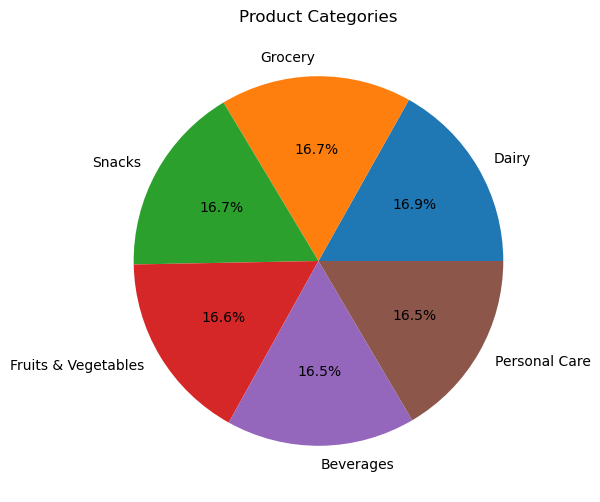

In [5]:
print(data["Product Category"].value_counts())
print("----------------------------")
plt.figure(figsize=(8,6))
data["Product Category"].value_counts().plot(kind ="pie",autopct='%1.1f%%')
plt.title("Product Categories")
plt.ylabel("")
plt.show()

Platform
Swiggy Instamart    33449
Blinkit             33424
JioMart             33127
Name: count, dtype: int64
---------------------------------


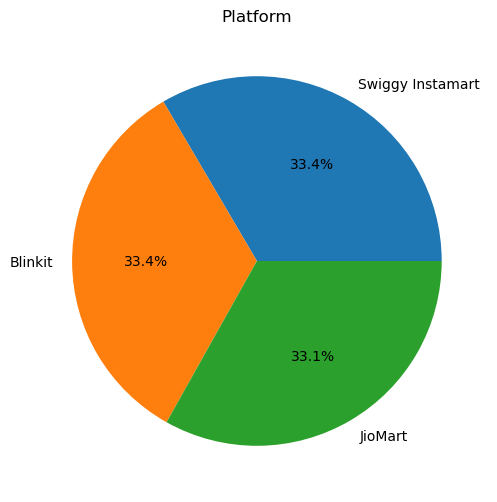

In [6]:
print(data["Platform"].value_counts())
print("---------------------------------")
plt.figure(figsize=(8,6))
data["Platform"].value_counts().plot(kind ="pie",autopct='%1.1f%%')
plt.title("Platform")
plt.ylabel("")
plt.show()

Service Rating
5    38688
2    30552
1    15267
4     7789
3     7704
Name: count, dtype: int64
----------------------------


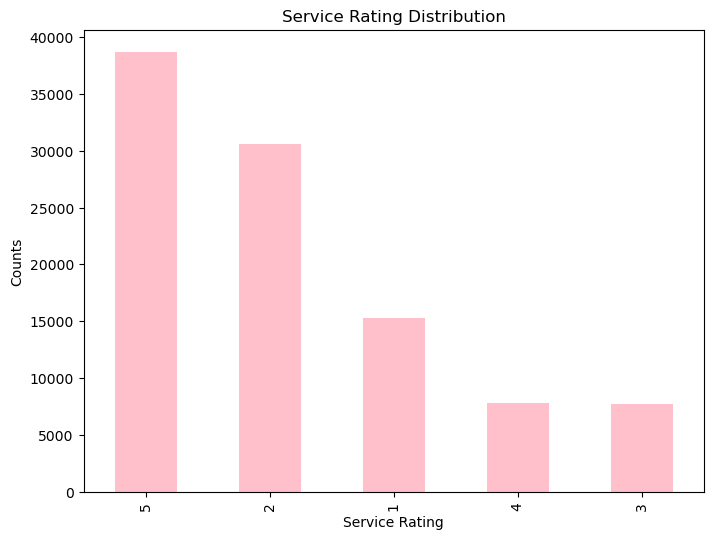

In [7]:
plt.figure(figsize=(8,6))
print(data["Service Rating"].value_counts())
print("----------------------------")
data["Service Rating"].value_counts().plot(kind = "bar" , color = "pink")
plt.title("Service Rating Distribution")
plt.ylabel("Counts")
plt.show()

Delivery Delay
No     86328
Yes    13672
Name: count, dtype: int64
------------------------------------


Text(0.5, 1.0, 'Delivery Delay Chances')

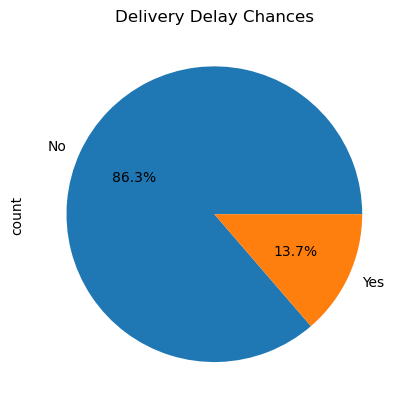

In [8]:
print(data["Delivery Delay"].value_counts())
print("------------------------------------")
data["Delivery Delay"].value_counts().plot(kind = "pie", autopct='%1.1f%%')
plt.title("Delivery Delay Chances")

Refund Requested
No     54181
Yes    45819
Name: count, dtype: int64
----------------------------------------


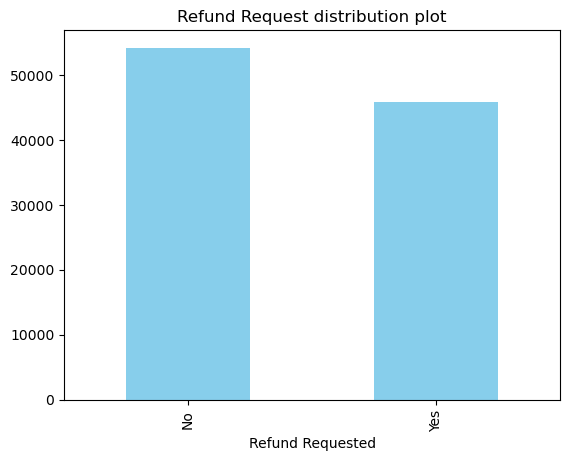

In [9]:
print(data["Refund Requested"].value_counts())
print("----------------------------------------")
data["Refund Requested"].value_counts().plot(kind = "bar" , color = "skyblue")
plt.title("Refund Request distribution plot")
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score , classification_report,confusion_matrix

In [11]:
data.drop(columns = ["Order ID","Customer ID"],inplace = True)

In [12]:
data.select_dtypes(include="object")

,Platform,Order Date & Time,Product Category,Customer Feedback,Delivery Delay,Refund Requested
0,JioMart,19:29.5,Fruits & Vegetables,"Fast delivery, great service!",No,No
1,Blinkit,54:29.5,Dairy,Quick and reliable!,No,No
2,JioMart,21:29.5,Beverages,Items missing from order.,No,Yes
3,JioMart,19:29.5,Beverages,Items missing from order.,Yes,Yes
4,Blinkit,49:29.5,Beverages,"Fast delivery, great service!",No,No
...,...,...,...,...,...,...
99995,JioMart,49:29.5,Dairy,Packaging could be better.,No,No
99996,JioMart,18:29.5,Snacks,Good quality products.,No,No
99997,JioMart,27:29.5,Dairy,"Fast delivery, great service!",Yes,No
99998,JioMart,14:29.5,Grocery,Quick and reliable!,No,No


In [13]:
label_encoder ={}
categorical_col = ["Platform","Product Category","Customer Feedback","Delivery Delay","Refund Requested"]
for i in categorical_col:
    le = LabelEncoder()
    data[i] = le.fit_transform(data[i])
    data[i] = data[i].astype(float)
    label_encoder[i] = le

In [14]:
data.head()

,Platform,Order Date & Time,Delivery Time (Minutes),Product Category,Order Value (INR),Customer Feedback,Service Rating,Delivery Delay,Refund Requested
0,1.0,19:29.5,30,2.0,382,3.0,5,0.0,0.0
1,0.0,54:29.5,16,1.0,279,9.0,5,0.0,0.0
2,1.0,21:29.5,25,0.0,599,6.0,2,0.0,1.0
3,1.0,19:29.5,42,0.0,946,6.0,2,1.0,1.0
4,0.0,49:29.5,30,0.0,334,3.0,5,0.0,0.0


In [15]:
if "Order Date & Time" in data.columns:
    data["Order Date & Time"] = pd.to_datetime(data["Order Date & Time"], errors='coerce')
    data.dropna(subset=["Order Date & Time"], inplace=True)  # Remove invalid dates
    data["Order Hour"] = data["Order Date & Time"].dt.hour
    data["Order Day of Week"] = data["Order Date & Time"].dt.dayofweek
    data["Order Month"] = data["Order Date & Time"].dt.month
    data.drop(columns=["Order Date & Time"], inplace=True)

In [16]:
data.columns

Index(['Platform', 'Delivery Time (Minutes)', 'Product Category',
       'Order Value (INR)', 'Customer Feedback', 'Service Rating',
       'Delivery Delay', 'Refund Requested', 'Order Hour', 'Order Day of Week',
       'Order Month'],
      dtype='object')

In [17]:
features = ["Platform", "Product Category", "Order Value (INR)", "Order Hour", "Order Day of Week", "Order Month", "Customer Feedback"]
target = 'Delivery Delay'

In [18]:
X = data[features].astype(float)
y = data[target]

In [19]:
X_train,X_test,y_train,y_test = train_test_split(X,y , test_size=0.20 ,random_state=42)

In [20]:
lr = LogisticRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)
print("Testing Score =",lr.score(X_test,y_test))
print("Training score =",lr.score(X_train,y_train))
print("accuracy score = ",accuracy_score(y_test , y_pred))
print("Confusion Metrics")
print(confusion_matrix(y_test,y_pred))
print("Classification report ")
print(classification_report(y_test,y_pred))

Testing Score = 0.8682199674307904
Training score = 0.8637559508895014
accuracy score =  0.8682199674307904
Confusion Metrics
[[6931    0]
 [1052    0]]
Classification report 
              precision    recall  f1-score   support

         0.0       0.87      1.00      0.93      6931
         1.0       0.00      0.00      0.00      1052

    accuracy                           0.87      7983
   macro avg       0.43      0.50      0.46      7983
weighted avg       0.75      0.87      0.81      7983



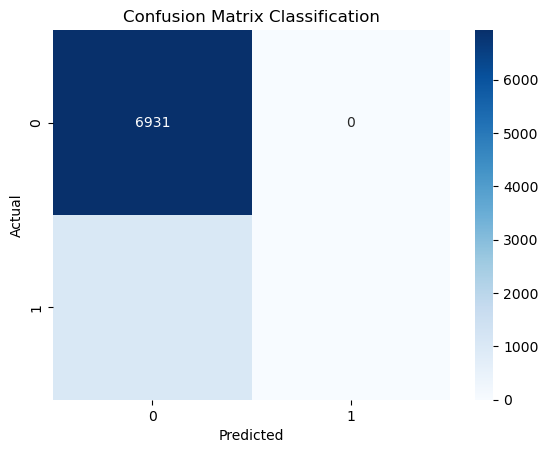

In [21]:
sns.heatmap(confusion_matrix(y_test,y_pred) ,annot = True,fmt= "d", cmap="Blues")
plt.title("Confusion Matrix Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [32]:
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)

print("Testing Score =",rf.score(X_test,y_test))
print("Training Score =",rf.score(X_train,y_train))

print("Accuracy Score =",accuracy_score(y_test,y_pred))
print("confusion matrixs")
print(confusion_matrix(y_test,y_pred))
print("Classification Report ")
print(classification_report(y_test,y_pred))



Testing Score = 0.8476763121633472
Training Score = 0.9990290653971435
Accuracy Score = 0.8476763121633472
confusion matrixs
[[6734  197]
 [1019   33]]
Classification Report 
              precision    recall  f1-score   support

         0.0       0.87      0.97      0.92      6931
         1.0       0.14      0.03      0.05      1052

    accuracy                           0.85      7983
   macro avg       0.51      0.50      0.48      7983
weighted avg       0.77      0.85      0.80      7983



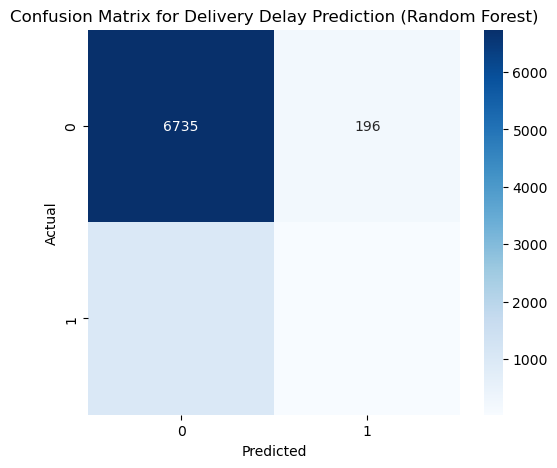

In [23]:
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Delivery Delay Prediction (Random Forest)")
plt.show()

In [24]:
from sklearn.tree import DecisionTreeClassifier
dc = DecisionTreeClassifier()
dc.fit(X_train,y_train)
y_pred = dc.predict(X_test)

print("Testing Score =",dc.score(X_test,y_test))
print("Training Score =",dc.score(X_train,y_train))

print("Accuracy Score =",accuracy_score(y_test,y_pred))
print("confusion matrixs")
print(confusion_matrix(y_test,y_pred))
print("Classification Report ")
print(classification_report(y_test,y_pred))

Testing Score = 0.7546035325065765
Training Score = 0.9991230268103233
Accuracy Score = 0.7546035325065765
confusion matrixs
[[5866 1065]
 [ 894  158]]
Classification Report 
              precision    recall  f1-score   support

         0.0       0.87      0.85      0.86      6931
         1.0       0.13      0.15      0.14      1052

    accuracy                           0.75      7983
   macro avg       0.50      0.50      0.50      7983
weighted avg       0.77      0.75      0.76      7983



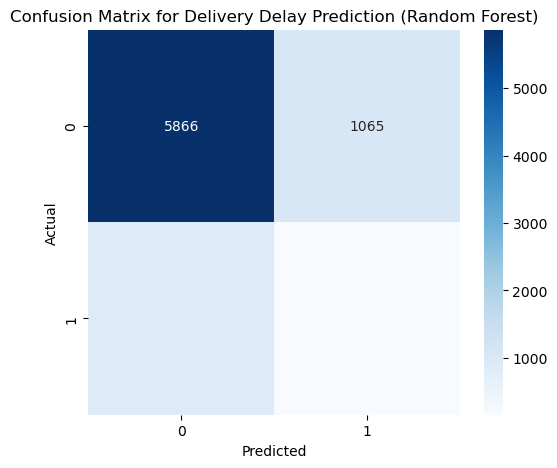

In [25]:
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Delivery Delay Prediction (Random Forest)")
plt.show()